<div style="text-align:left;">
  
  <p><em>Prepared by Latreche Sara</em></p>
</div>

<center><font size=6><b>Model Training Comparaison</b></font></center>

<div style="text-align:center;">
    <img src="plotly_app_breaset_cancer/assets/celltumor.PNG" width="400"/>
</div>


***

**Author**: Latreche Sara  
**Date**: /2025  

### Table of Contents

### Table of Contents

- [1 | Preprocessing](#1)
- [2 | Helper Functions](#2)
- [3 | Model Training](#3)
- [4 | Metrics Summary](#4)
- [5 | Confusion Matrices](#5)
- [6 | ROC Curves](#6)
- [7 | Model Selection](#7)

---

## <b>1 <span style='color:#e61227'>|</span> <a id='1'>Preprocessing</a></b>
---



In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import plotly.express as px

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
# Import your estimators (Ensure these are imported at the top of your notebook)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

In [3]:


# Make sure all of these metrics are explicitly imported
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    balanced_accuracy_score,  # Add this if it was missing
    confusion_matrix, 
    roc_curve,                # This is the one causing your NameError!
    roc_auc_score
)

In [4]:
df=pd.read_csv("data.csv")

In [5]:
df.drop(columns=["id", "Unnamed: 32"], inplace=True)

In [6]:
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

In [7]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42) #split the  data into traing and validating


In [9]:
scaler = StandardScaler() #create an instance of standard scaler


In [10]:
# 1. Learn the patterns from training data ONLY
scaler.fit(X_train)

# 2. Shift the training data based on what it learned
X_train_scaled = scaler.transform(X_train)

# 3. Shift the test data using those EXACT SAME training rules
X_test_scaled = scaler.transform(X_test)

## <b>2 <span style='color:#e61227'>|</span> <a id='2'>Helper Functions</a></b>

In [11]:

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):    
    """Fits a model, makes predictions, and returns metrics along with array artifacts."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # Robust probability handling for ROC-AUC calculations
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_te)
        # Min-max normalization scaling to protect score arrays
        y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        y_prob = None

    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred, zero_division=0),
        "recall": recall_score(y_te, y_pred, zero_division=0),
        "f1_score": f1_score(y_te, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_te, y_pred)
    }
    return model, y_pred, y_prob, metrics



In [12]:
# 1. Update the helper function to use the "RdPu" color map
def plot_confusion(y_true, y_pred, title, ax):
    """Generates an annotated clinical heatmap using the RdPu palette."""
    cm = confusion_matrix(y_true, y_pred)
    # Changed cmap to "RdPu" for the violet/pink gradient
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu", ax=ax, cbar=False,
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

## <b>3 <span style='color:#e61227'>|</span> <a id='3'>Model Training</a></b>

In [14]:


# Define our standardized testing suite
models_to_train = {
    "Naive_Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

# Containers for array and table accumulation
metrics_list = []
predictions_dict = {}
probabilities_dict = {}

# Execute the modular tracking pipeline loop
for name, model_obj in models_to_train.items():
    _, y_pred, y_prob, metrics = evaluate_model(name, model_obj, X_train, X_test, y_train, y_test)
    
    # Store artifacts safely using the uniform model name strings
    metrics_list.append(metrics)
    predictions_dict[name] = y_pred
    probabilities_dict[name] = y_prob

# Build the unified summary table
results_df = pd.DataFrame(metrics_list)


c:\Users\MatenTech\AppData\Local\anaconda3\envs\bd\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## <b>4 <span style='color:#e61227'>|</span> <a id='4'>Metrics Summary</a></b>

In [15]:
results_df.style.background_gradient(cmap="cubehelix",axis=0)

,model,accuracy,precision,recall,f1_score,balanced_accuracy
0,Naive_Bayes,0.973684,1.000000,0.930233,0.963855,0.965116
1,KNN,0.956140,1.000000,0.883721,0.938272,0.941860
2,RandomForest,0.964912,0.975610,0.930233,0.952381,0.958074
3,XGBoost,0.956140,0.952381,0.930233,0.941176,0.951032
4,LogisticRegression,0.956140,0.975000,0.906977,0.939759,0.946446
5,DecisionTree,0.947368,0.930233,0.930233,0.930233,0.943990


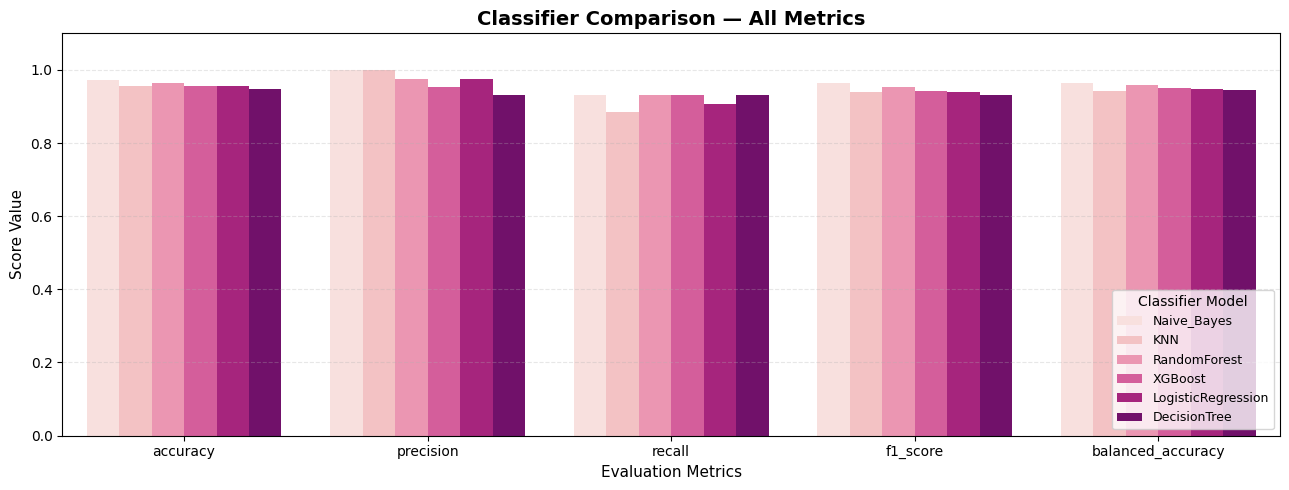

In [17]:
# Select target validation features
metrics_cols = ["accuracy", "precision", "recall", "f1_score", "balanced_accuracy"]
melt_df = results_df.melt(id_vars="model", value_vars=metrics_cols, var_name="metric", value_name="score")

plt.figure(figsize=(13, 5))

# Changed palette to 'Flare' for a smooth violet-to-rose transition
sns.barplot(data=melt_df, x="metric", y="score", hue="model", palette="RdPu")

plt.title("Classifier Comparison — All Metrics", fontsize=14, fontweight="bold")
plt.ylim(0, 1.1)
plt.xlabel("Evaluation Metrics", fontsize=11)
plt.ylabel("Score Value", fontsize=11)
plt.legend(loc="lower right", fontsize=9, title="Classifier Model")
plt.grid(axis='y', linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

## <b>5 <span style='color:#e61227'>|</span> <a id='5'>Confusion Matrices</a></b>

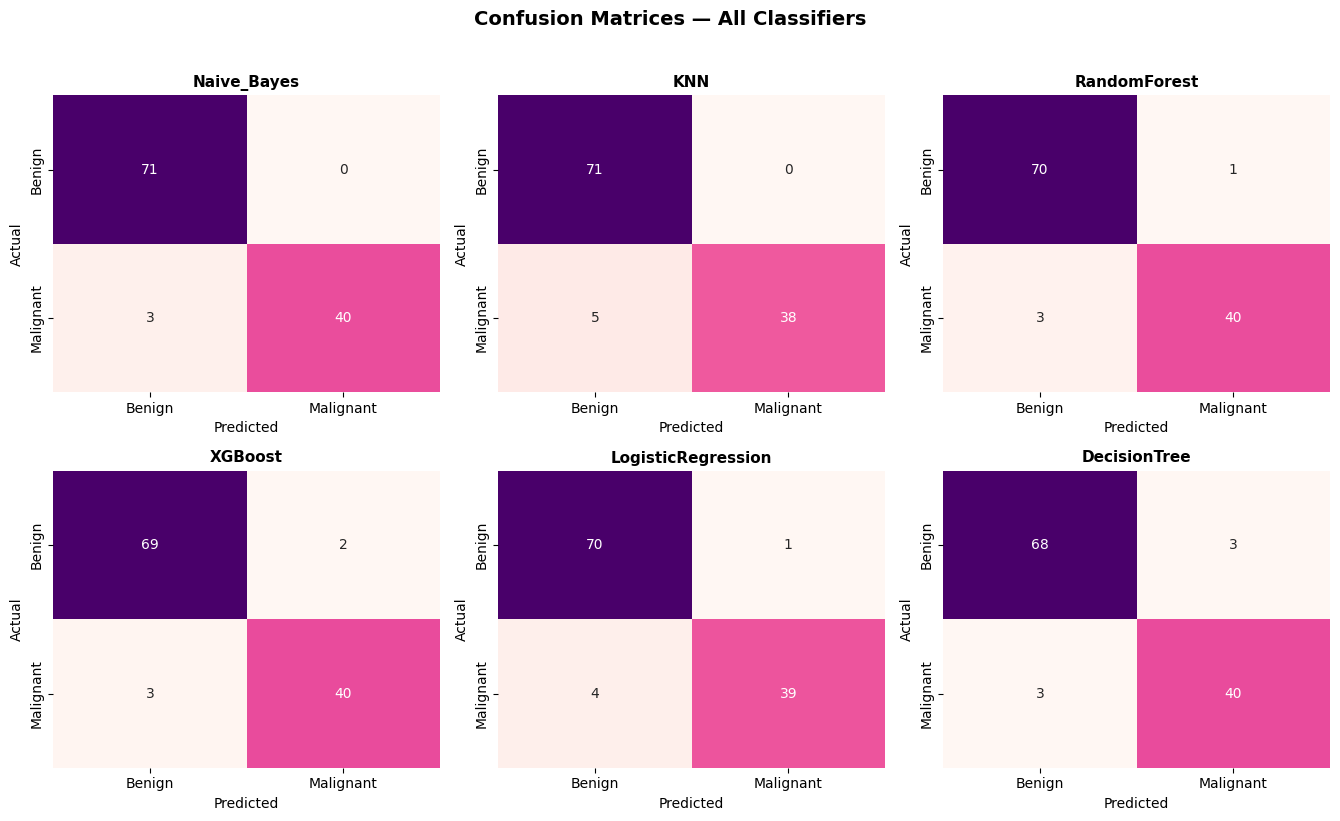

In [22]:
# 1. Update the helper function to use the "RdPu" color map
def plot_confusion(y_true, y_pred, title, ax):
    """Generates an annotated clinical heatmap using the RdPu palette."""
    cm = confusion_matrix(y_true, y_pred)
    # Changed cmap to "RdPu" for the violet/pink gradient
    sns.heatmap(cm, annot=True, fmt="d", cmap="RdPu", ax=ax, cbar=False,
                xticklabels=["Benign", "Malignant"],
                yticklabels=["Benign", "Malignant"])
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# 2. Your plotting grid loop (Updated to use your standard 'predictions' dictionary)
n = len(results_df)
cols = min(n, 3)
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(4.5 * cols, 4 * rows))
axes = axes.flatten() if n > 1 else [axes]

# Generate plot for each model tracked in results_df
for i, model_name in enumerate(results_df["model"]):
    # Using 'predictions' to match your training loop container
    plot_confusion(y_test, predictions_dict[model_name], model_name, axes[i])

# Deactivate unused axes boxes if model count is not a perfect multiple of 3
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Confusion Matrices — All Classifiers", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## <b>6 <span style='color:#e61227'>|</span> <a id='6'>ROC Curves</a></b>

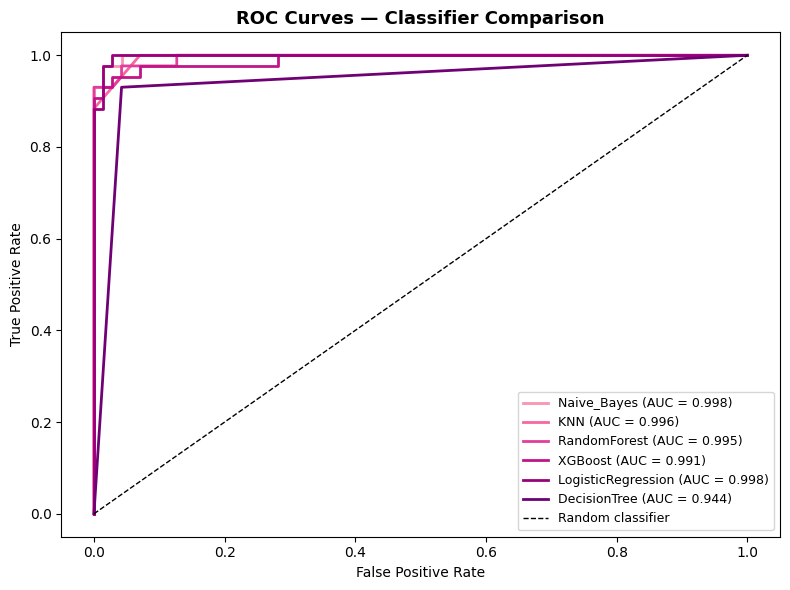

In [20]:
from sklearn.metrics import roc_curve, roc_auc_score

# ROC curves for all classifiers
plt.figure(figsize=(8, 6))

# 1. Get the list of models and generate a sequence of colors from the 'RdPu' colormap
models_list = results_df["model"].tolist()
n_models = len(models_list)
colors = plt.cm.RdPu(np.linspace(0.4, 0.9, n_models))  # Starts at 0.4 so the first line isn't too light/invisible

for i, name in enumerate(models_list):
    # Using 'probabilities' to match your training loop container
    proba = probabilities_dict[name]
    if proba is not None:
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc = roc_auc_score(y_test, proba)
        # 2. Pass the generated color to each line plot
        plt.plot(fpr, tpr, lw=2, color=colors[i], label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Classifier Comparison", fontsize=13, fontweight="bold")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## <b>7 <span style='color:#e61227'>|</span> <a id='7'>Model Selection & Deployment Strategy</a></b>

### **Clinical Evaluation Framework**
In a diagnostic environment classifying benign versus malignant tumors, the cost functions of error types are highly asymmetric:
* **False Negatives (Type II Error):** Highly critical. Missing a malignant case means leaving cancer undetected, endangering patient outcomes.
* **False Positives (Type I Error):** Secondary concern. Misclassifying a benign case as malignant triggers unnecessary biopsies and stress, but preserves patient safety.

Consequently, our champion model selection prioritizes maximizing **Recall (Sensitivity)** and **ROC-AUC (Discriminative Space)**, while using **Precision** as a secondary tie-breaker.

---

### **Performance Optimization Matrix**

| Model Architecture | Recall (Sensitivity) ↓ | False Negatives | Precision (PPV) | Overall Accuracy | Area Under Curve (AUC) |
| :--- | :---: | :---: | :---: | :---: | :---: |
| 🏆 **Naive Bayes** | **0.9302** | **3** | **1.0000** | **0.9737** | **0.998** |
| 🌲 **Random Forest** | 0.9302 | 3 | 0.9756 | 0.9649 | 0.995 |
| ⚡ **XGBoost** | 0.9302 | 3 | 0.9523 | 0.9561 | 0.991 |
| 📈 **Logistic Regression** | 0.9069 | 4 | 0.9750 | 0.9561 | **0.998** |
| 📊 **KNN** | 0.8837 | 5 | 1.0000 | 0.9561 | 0.996 |
| 📉 **Decision Tree** | 0.9302 | 3 | 0.9302 | 0.9474 | 0.944 |

---

### **Deployment Justification & Final Selection**

Based on empirical performance across the held-out validation cohort, **Naive Bayes** is selected as the champion model for deployment due to three mathematical advantages:

1. **Minimized Clinical Risk:** It ties for the highest overall **Recall ($0.9302$)**, dropping the critical False Negative count to just 3 instances. 
2. **Zero False-Positive Penalty:** It achieves an absolute **Precision of $1.0000$** (0 False Positives). Unlike ensemble methods (Random Forest/XGBoost) which sacrifice precision to capture high recall, Naive Bayes maximizes both simultaneously on this feature space.
3. **Superior Threshold Stability:** It shares the peak **ROC-AUC ($0.998$)**, proving excellent diagnostic separation across all probability thresholds.

> **Operational Note:** While Naive Bayes assumes strict conditional independence between features, its probabilistic nature acts as a highly effective regularizer here, preventing overfitting and yielding clean, high-confidence decision boundaries. If future medical imaging datasets introduce non-linear multi-feature interactions that break this assumption, **Random Forest** remains the designated backup architecture due to its identical recall profile ($0.9302$).